In [2]:
from orcs.process import SpectralCube
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import orb
import orb.utils.graph as graph
from scipy import constants
import pyregion

import numpy as np
import matplotlib.pyplot as plt
import orcs.process
import orcs.process
import pylab as pl
import orb.utils.io
import numpy as np
from importlib import reload
import pyregion
import orb.utils.graph as graph
from orcs.process import SpectralCube
import pylab as pl
import orb.utils.io
import numpy as np
import matplotlib.pyplot as plt

import orcs.process
import pylab as pl
import orb.utils.io
import numpy as np
from importlib import reload
import pyregion
import orb.utils.graph as graph
from orcs.process import SpectralCube
import pylab as pl
import orb.utils.io
import numpy as np
import matplotlib.pyplot as plt
import astropy.cosmology as cosmo
from orcs.process import SpectralCube
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import orb
import orb.utils.graph as graph
from scipy import constants
import pyregion

In [3]:
cube_SN3 = SpectralCube('/Users/leianydeoleo/Desktop/IIZw96/SN3.hdf5')

unknown|WARNING| old cube architecture (level 1). IO performances could be reduced.
unknown|INFO| Cube is level 1
unknown|INFO| shape: (2048, 2064, 419)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: False



========== MOFFAT FIT ==========
Amplitude : 52251494.51
Gamma     : 6.999 pixels
Alpha     : 8.370
--------------------------------
FWHM       : 4.11 pixels
Seeing     : 1.32 arcsec


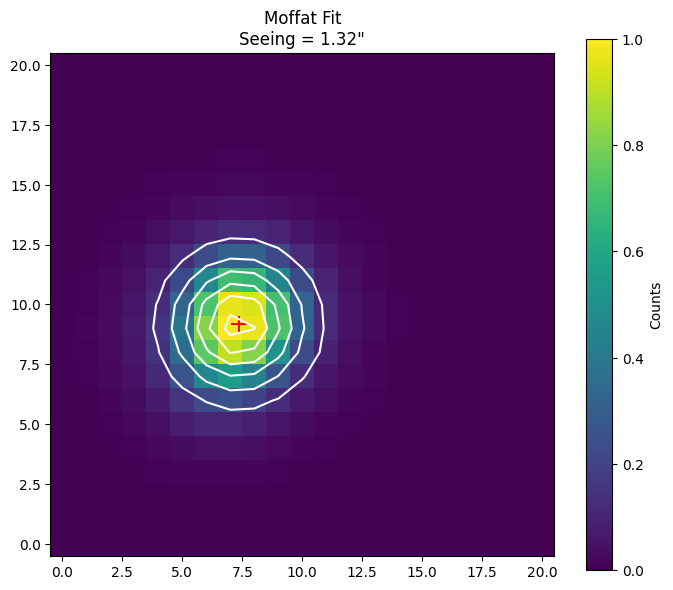

In [4]:
import re
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.modeling import models, fitting


image_file = "/Users/leianydeoleo/Desktop/IIZW96/deep_frameSN3.fits"
region_file = "/Users/leianydeoleo/Desktop/IIZW96/starSN3.reg"

pixel_scale = 0.32      # arcsec/pixel

# Read image

image = fits.getdata(image_file)

# Read DS9 circle region

with open(region_file) as f:
    text = f.read()

match = re.search(r'circle\(([^,]+),([^,]+),([^)]+)\)', text)

if match is None:
    raise ValueError("No circular region found.")

xc = float(match.group(1))
yc = float(match.group(2))
r = float(match.group(3))

xc = int(round(xc))
yc = int(round(yc))
r = int(np.ceil(r))


# Cutout
cutout = image[
    yc-r:yc+r+1,
    xc-r:xc+r+1
]


# Background subtraction

background = np.nanmedian(cutout)
cutout = cutout - background
cutout[cutout < 0] = 0


# Coordinates
yy, xx = np.mgrid[:cutout.shape[0], :cutout.shape[1]]


# Initial Moffat model
m_init = models.Moffat2D(
    amplitude=np.nanmax(cutout),
    x_0=cutout.shape[1]/2,
    y_0=cutout.shape[0]/2,
    gamma=2.0,
    alpha=3.5
)

fit = fitting.LevMarLSQFitter()

m = fit(m_init, xx, yy, cutout)

# Compute FWHM
gamma = m.gamma.value
alpha = m.alpha.value

fwhm_pix = 2 * gamma * np.sqrt(2**(1/alpha) - 1)

fwhm_arcsec = fwhm_pix * pixel_scale

# Results
print("\n========== MOFFAT FIT ==========")

print(f"Amplitude : {m.amplitude.value:.2f}")
print(f"Gamma     : {gamma:.3f} pixels")
print(f"Alpha     : {alpha:.3f}")

print("--------------------------------")

print(f"FWHM       : {fwhm_pix:.2f} pixels")
print(f"Seeing     : {fwhm_arcsec:.2f} arcsec")

# Plot
plt.figure(figsize=(7,6))

plt.imshow(cutout,
           origin='lower',
           cmap='viridis')

plt.contour(
    m(xx,yy),
    colors='white',
    linewidths=1.5
)

plt.scatter(m.x_0.value,
            m.y_0.value,
            marker='+',
            color='red',
            s=120)

plt.title(f"Moffat Fit\nSeeing = {fwhm_arcsec:.2f}\"")

plt.colorbar(label='Counts')

plt.tight_layout()

plt.show()

unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/gwcs/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound



Detected stars : 2001
After saturation cut : 809
After edge cut : 804
Isolated stars : 675

Fits passing quality cuts: 416
After sigma clipping: 374

FINAL SEEING
Accepted stars : 374
Mean seeing    : 1.082"
Median seeing  : 1.069"
Std            : 0.088"

Saved seeing_measurements.csv


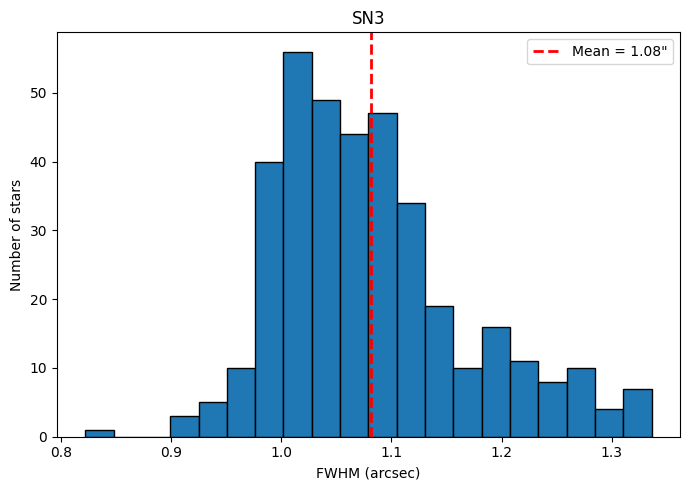

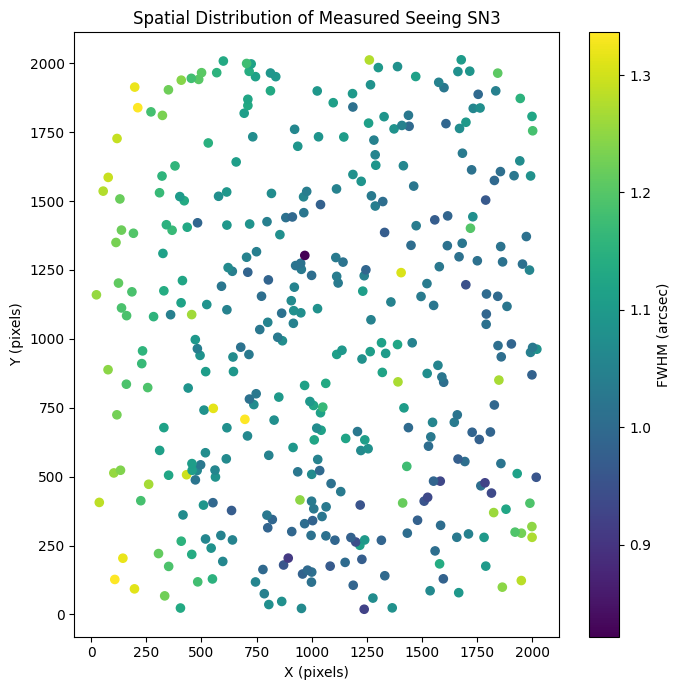

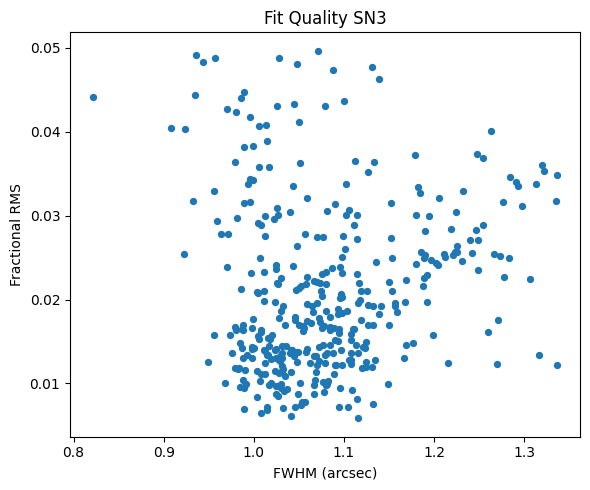

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from astropy.io import fits
from astropy.stats import sigma_clipped_stats, sigma_clip
from astropy.table import Table
from astropy.modeling import models, fitting

from photutils.detection import DAOStarFinder

from scipy.spatial import cKDTree



image_file = "/Users/leianydeoleo/Desktop/IIZW96/deep_frameSN3.fits"

pixel_scale = 0.32          # arcsec/pixel

# Source detection
fwhm_guess = 3.2            # pixels
threshold_sigma = 5.0

# PSF fitting
fit_radius = 10             # produces 21x21 cutout

# Source filtering
min_separation = 20         # pixels
max_peak = 60000            # saturation threshold

# Fit quality
max_fractional_rms = 0.05


# LOAD IMAGE
image = fits.getdata(image_file)


# BACKGROUND
mean, median, std = sigma_clipped_stats(image)


# DETECT SOURCES
finder = DAOStarFinder(
    fwhm=fwhm_guess,
    threshold=threshold_sigma * std
)

sources = finder(image - median)

if sources is None:
    raise RuntimeError("No stars detected.")

print(f"Detected stars : {len(sources)}")


# REMOVE SATURATED

sources = sources[sources["peak"] < max_peak]

print(f"After saturation cut : {len(sources)}")


# REMOVE EDGE STARS

margin = fit_radius + 2

sources = sources[
    (sources["xcentroid"] > margin) &
    (sources["xcentroid"] < image.shape[1]-margin) &
    (sources["ycentroid"] > margin) &
    (sources["ycentroid"] < image.shape[0]-margin)
]

print(f"After edge cut : {len(sources)}")


# REMOVE CROWDED STARS

coords = np.column_stack((
    sources["xcentroid"],
    sources["ycentroid"]
))

tree = cKDTree(coords)

keep = np.ones(len(coords), dtype=bool)

for i in range(len(coords)):

    neighbors = tree.query_ball_point(
        coords[i],
        r=min_separation
    )

    if len(neighbors) > 1:
        keep[i] = False

sources = sources[keep]

print(f"Isolated stars : {len(sources)}")


# FIT STARS
fit = fitting.LevMarLSQFitter()

results = []

for star in sources:

    xc = star["xcentroid"]
    yc = star["ycentroid"]

    x0 = int(round(xc))
    y0 = int(round(yc))

    cutout = image[
        y0-fit_radius:y0+fit_radius+1,
        x0-fit_radius:x0+fit_radius+1
    ].copy()

    yy, xx = np.mgrid[:cutout.shape[0], :cutout.shape[1]]

    r = np.sqrt(
    (xx - fit_radius)**2 +
    (yy - fit_radius)**2
    )

# annulus between 7 and 10 pixels
    mask = (r >= 7) & (r <= 10)

    background = np.median(cutout[mask])

    cutout = cutout - background
    cutout[cutout < 0] = 0

    yy, xx = np.mgrid[:cutout.shape[0], :cutout.shape[1]]

    model0 = models.Moffat2D(
        amplitude=cutout.max(),
        x_0=fit_radius,
        y_0=fit_radius,
        gamma=2.0,
        alpha=3.5
    )

    try:

        model = fit(model0, xx, yy, cutout)

        gamma = model.gamma.value
        alpha = model.alpha.value

    
        # Reject bad parameters
        if gamma <= 0:
            continue

        if alpha <= 1:
            continue

        if alpha > 20:
            continue

        fwhm_pix = (
            2 * gamma *
            np.sqrt(2**(1/alpha) - 1)
        )

        fwhm_arcsec = fwhm_pix * pixel_scale

        # broad physical limits

        if not (0.5 < fwhm_arcsec < 2.0):
            continue

        
        # Residuals

        model_image = model(xx, yy)

        residual = cutout - model_image

        rms = np.sqrt(
            np.mean(residual**2)
        )

        fractional_rms = rms / model.amplitude.value

        if fractional_rms > max_fractional_rms:
            continue

        results.append([
            xc,
            yc,
            fwhm_pix,
            fwhm_arcsec,
            gamma,
            alpha,
            fractional_rms
        ])

    except Exception:
        continue

# TABLE

results = Table(
    rows=results,
    names=[
        "x",
        "y",
        "fwhm_pix",
        "fwhm_arcsec",
        "gamma",
        "alpha",
        "fractional_rms"
    ]
)

print()
print("Fits passing quality cuts:", len(results))


# SIGMA CLIP FINAL FWHM

mask = sigma_clip(
    results["fwhm_arcsec"],
    sigma=3,
    maxiters=5
)

results = results[~mask.mask]

print("After sigma clipping:", len(results))


# FINAL STATISTICS

mean = np.mean(results["fwhm_arcsec"])
median = np.median(results["fwhm_arcsec"])
std = np.std(results["fwhm_arcsec"])

print("\n==============================")
print("FINAL SEEING")
print("==============================")
print(f"Accepted stars : {len(results)}")
print(f"Mean seeing    : {mean:.3f}\"")
print(f"Median seeing  : {median:.3f}\"")
print(f"Std            : {std:.3f}\"")

# SAVE TABLE

results.write(
    "seeing_measurements.csv",
    overwrite=True
)

print("\nSaved seeing_measurements.csv")


# HISTOGRAM

plt.figure(figsize=(7,5))

plt.hist(
    results["fwhm_arcsec"],
    bins=20,
    edgecolor="black"
)

plt.axvline(
    mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean:.2f}\""
)

plt.xlabel("FWHM (arcsec)")
plt.ylabel("Number of stars")
plt.legend()
plt.title("SN3")

plt.tight_layout()


# SPATIAL MAP
plt.figure(figsize=(7,7))

plt.scatter(
    results["x"],
    results["y"],
    c=results["fwhm_arcsec"],
    cmap="viridis",
    s=35
)

plt.colorbar(label="FWHM (arcsec)")

plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.title("Spatial Distribution of Measured Seeing SN3")

plt.tight_layout()


# FIT QUALITY
plt.figure(figsize=(6,5))

plt.scatter(
    results["fwhm_arcsec"],
    results["fractional_rms"],
    s=18
)

plt.xlabel("FWHM (arcsec)")
plt.ylabel("Fractional RMS")
plt.title("Fit Quality SN3")

plt.tight_layout()

plt.show()


# OPTIONAL: SAVE PANDAS CSV
df = results.to_pandas()

df.to_csv(
    "seeing_measurements_pandas.csv",
    index=False
)



Detected stars : 1980
After saturation cut : 1028
After edge cut : 1017
Isolated stars : 789

Fits passing quality cuts: 514
After sigma clipping: 486

FINAL SEEING
Accepted stars : 486
Mean seeing    : 0.877"
Median seeing  : 0.862"
Std            : 0.115"

Saved seeing_measurements.csv


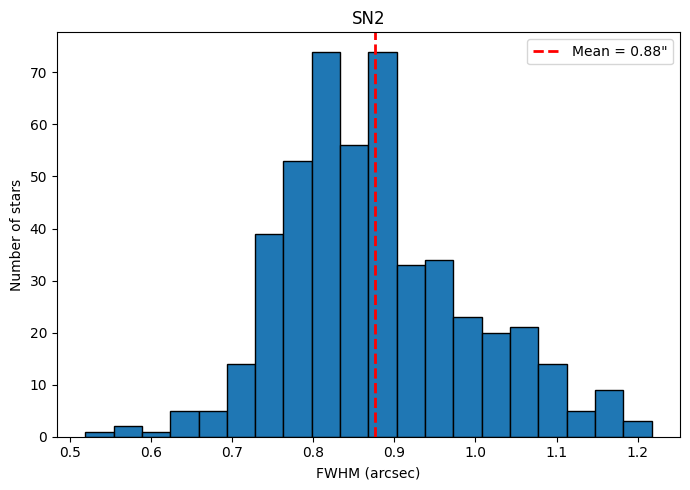

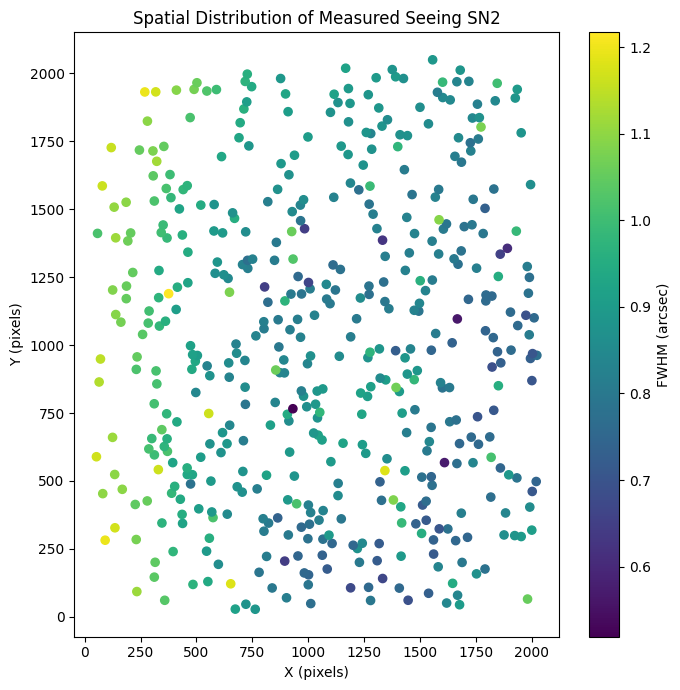

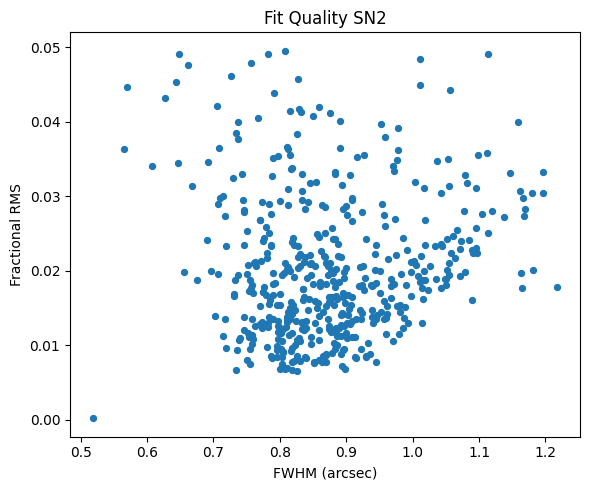

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from astropy.io import fits
from astropy.stats import sigma_clipped_stats, sigma_clip
from astropy.table import Table
from astropy.modeling import models, fitting

from photutils.detection import DAOStarFinder

from scipy.spatial import cKDTree


image_file = "/Users/leianydeoleo/Desktop/IIZW96/deep_frame.fits"

pixel_scale = 0.32          # arcsec/pixel

# Source detection
fwhm_guess = 3.2            # pixels
threshold_sigma = 5.0

# PSF fitting
fit_radius = 10             # produces 21x21 cutout

# Source filtering
min_separation = 20         # pixels
max_peak = 60000            # saturation threshold

# Fit quality
max_fractional_rms = 0.05

# LOAD IMAGE
image = fits.getdata(image_file)


# BACKGROUND
mean, median, std = sigma_clipped_stats(image)


# DETECT SOURCES
finder = DAOStarFinder(
    fwhm=fwhm_guess,
    threshold=threshold_sigma * std
)

sources = finder(image - median)

if sources is None:
    raise RuntimeError("No stars detected.")

print(f"Detected stars : {len(sources)}")


# REMOVE SATURATED
sources = sources[sources["peak"] < max_peak]

print(f"After saturation cut : {len(sources)}")


# REMOVE EDGE STARS
margin = fit_radius + 2

sources = sources[
    (sources["xcentroid"] > margin) &
    (sources["xcentroid"] < image.shape[1]-margin) &
    (sources["ycentroid"] > margin) &
    (sources["ycentroid"] < image.shape[0]-margin)
]

print(f"After edge cut : {len(sources)}")


# REMOVE CROWDED STARS
coords = np.column_stack((
    sources["xcentroid"],
    sources["ycentroid"]
))

tree = cKDTree(coords)

keep = np.ones(len(coords), dtype=bool)

for i in range(len(coords)):

    neighbors = tree.query_ball_point(
        coords[i],
        r=min_separation
    )

    if len(neighbors) > 1:
        keep[i] = False

sources = sources[keep]

print(f"Isolated stars : {len(sources)}")


# FIT STARS
fit = fitting.LevMarLSQFitter()

results = []

for star in sources:

    xc = star["xcentroid"]
    yc = star["ycentroid"]

    x0 = int(round(xc))
    y0 = int(round(yc))

    cutout = image[
        y0-fit_radius:y0+fit_radius+1,
        x0-fit_radius:x0+fit_radius+1
    ].copy()

    yy, xx = np.mgrid[:cutout.shape[0], :cutout.shape[1]]

    r = np.sqrt(
    (xx - fit_radius)**2 +
    (yy - fit_radius)**2
    )

# annulus between 7 and 10 pixels
    mask = (r >= 7) & (r <= 10)

    background = np.median(cutout[mask])

    cutout = cutout - background
    cutout[cutout < 0] = 0

    yy, xx = np.mgrid[:cutout.shape[0], :cutout.shape[1]]

    model0 = models.Moffat2D(
        amplitude=cutout.max(),
        x_0=fit_radius,
        y_0=fit_radius,
        gamma=2.0,
        alpha=3.5
    )

    try:

        model = fit(model0, xx, yy, cutout)

        gamma = model.gamma.value
        alpha = model.alpha.value

        
        # Reject bad parameters
        
        if gamma <= 0:
            continue

        if alpha <= 1:
            continue

        if alpha > 20:
            continue

        fwhm_pix = (
            2 * gamma *
            np.sqrt(2**(1/alpha) - 1)
        )

        fwhm_arcsec = fwhm_pix * pixel_scale

        # broad physical limits

        if not (0.5 < fwhm_arcsec < 2.0):
            continue

        
        # Residuals
        
        model_image = model(xx, yy)

        residual = cutout - model_image

        rms = np.sqrt(
            np.mean(residual**2)
        )

        fractional_rms = rms / model.amplitude.value

        if fractional_rms > max_fractional_rms:
            continue

        results.append([
            xc,
            yc,
            fwhm_pix,
            fwhm_arcsec,
            gamma,
            alpha,
            fractional_rms
        ])

    except Exception:
        continue


# TABLE
results = Table(
    rows=results,
    names=[
        "x",
        "y",
        "fwhm_pix",
        "fwhm_arcsec",
        "gamma",
        "alpha",
        "fractional_rms"
    ]
)

print()
print("Fits passing quality cuts:", len(results))


# SIGMA CLIP FINAL FWHM

mask = sigma_clip(
    results["fwhm_arcsec"],
    sigma=3,
    maxiters=5
)

results = results[~mask.mask]

print("After sigma clipping:", len(results))


# FINAL STATISTICS

mean = np.mean(results["fwhm_arcsec"])
median = np.median(results["fwhm_arcsec"])
std = np.std(results["fwhm_arcsec"])

print("\n==============================")
print("FINAL SEEING")
print("==============================")
print(f"Accepted stars : {len(results)}")
print(f"Mean seeing    : {mean:.3f}\"")
print(f"Median seeing  : {median:.3f}\"")
print(f"Std            : {std:.3f}\"")


# SAVE TABLE

results.write(
    "seeing_measurements.csv",
    overwrite=True
)

print("\nSaved seeing_measurements.csv")


# HISTOGRAM

plt.figure(figsize=(7,5))

plt.hist(
    results["fwhm_arcsec"],
    bins=20,
    edgecolor="black"
)

plt.axvline(
    mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean:.2f}\""
)

plt.xlabel("FWHM (arcsec)")
plt.ylabel("Number of stars")
plt.legend()
plt.title("SN2")

plt.tight_layout()


# SPATIAL MAP

plt.figure(figsize=(7,7))

plt.scatter(
    results["x"],
    results["y"],
    c=results["fwhm_arcsec"],
    cmap="viridis",
    s=35
)

plt.colorbar(label="FWHM (arcsec)")

plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.title("Spatial Distribution of Measured Seeing SN2")

plt.tight_layout()


# FIT QUALITY
plt.figure(figsize=(6,5))

plt.scatter(
    results["fwhm_arcsec"],
    results["fractional_rms"],
    s=18
)

plt.xlabel("FWHM (arcsec)")
plt.ylabel("Fractional RMS")
plt.title("Fit Quality SN2")

plt.tight_layout()

plt.show()

# OPTIONAL: SAVE PANDAS CSV

df = results.to_pandas()

df.to_csv(
    "seeing_measurements_pandas.csv",
    index=False
)



In [8]:
import numpy as np


# SITELLE SN3 spectral resolution

c = 299792.458          # km/s
R = cube_SN3.params.resolution          # resolving power at Hα
lambda0 = 656.3        # nm

# Wavelength resolution
delta_lambda = lambda0 / R

# Velocity resolution (FWHM)
delta_v = c / R

# Gaussian sigma equivalent
sigma_inst = delta_v / (2.35482)

print("========== SITELLE SN3 ==========")
print(f"Resolving power (R)     = {R:.1f}")
print(f"Central wavelength      = {lambda0:.1f} nm")
print(f"Δλ (FWHM)               = {delta_lambda:.3f} nm")
print(f"Spectral resolution     = {delta_v:.2f} km/s")
print(f"Instrumental σ          = {sigma_inst:.2f} km/s")

========== SITELLE SN3 ==========
Resolving power (R)     = 2331.5
Central wavelength      = 656.3 nm
Δλ (FWHM)               = 0.281 nm
Spectral resolution     = 128.58 km/s
Instrumental σ          = 54.60 km/s


In [2]:
cube_SN3 = SpectralCube('/Users/leianydeoleo/Desktop/IIZw96/SN3.hdf5')
print('channel width (cm-1)', cube_SN3.params.base_axis[1] - cube_SN3.params.base_axis[0])
print('line width (cm-1)', cube_SN3.params.line_fwhm / 1.20671)
print('number of steps at the right of ZPD (contributing to the resolution)', cube_SN3.params.step_nb - cube_SN3.params.zpd_index)
print('ratio of the step number / the number of steps at the right of the ZPD', cube_SN3.params.step_nb / float(cube_SN3.params.step_nb - cube_SN3.params.zpd_index))
print('channel width (cm-1)', cube_SN3.params.line_fwhm / 1.20671 / 1.25)
print('Spectral resolution: ', cube_SN3.params.resolution)
mean_cm1 = (cube_SN3.params.base_axis[-1] + cube_SN3.params.base_axis[0]) / 2
print('Mean wavenumber', mean_cm1)
line_fwhm = mean_cm1 / cube_SN3.params.resolution
print('Line width (cm-1)',  line_fwhm)
print('channel width (cm-1)', line_fwhm / 1.20671 / 1.25)

unknown|WARNING| old cube architecture (level 1). IO performances could be reduced.
unknown|INFO| Cube is level 1
unknown|INFO| shape: (2048, 2064, 419)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: False


channel width (cm-1) 4.206213201823629788
line width (cm-1) 5.324481364242122
number of steps at the right of ZPD (contributing to the resolution) 331
ratio of the step number / the number of steps at the right of the ZPD 1.2658610271903323
channel width (cm-1) 4.2595850913936975
Spectral resolution:  2331.546104697898
Mean wavenumber 14978.325211694301288
Line width (cm-1) 6.424202884735605749
channel width (cm-1) 4.2589870870287681506


In [24]:
h5_file = "/Users/leianydeoleo/Desktop/IIZw96/SN3.hdf5"
flux_file = "/Users/leianydeoleo/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits"
vel_file = "/Users/leianydeoleo/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.velocity.fits"
disp_file = "/Users/leianydeoleo/IIZW96_SN3/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.sigma.fits"

No robust positive emission to contour.


In [26]:
print(wave.min(), wave.max())
print(line_center)

14099.2266525 15857.42377086076
6562.8


In [14]:
import numpy as np
import orcs

fitted_cube_file = "/Users/leianydeoleo/Desktop/IIZw96/SN3.hdf5"
def angstrom_to_wavenumber(angstrom):
    return 1e8 / angstrom  # cm^-1

fitted_cube_file = fitted_cube_file
ha_center_angstrom = 6562.8
ha_half_width_angstrom = 4.0

ha_lo = angstrom_to_wavenumber(ha_center_angstrom + ha_half_width_angstrom)
ha_hi = angstrom_to_wavenumber(ha_center_angstrom - ha_half_width_angstrom)
if ha_lo > ha_hi:
    ha_lo, ha_hi = ha_hi, ha_lo

cube = orcs.process.SpectralCube(fitted_cube_file)

sp0 = cube.get_spectrum(0, 0, 0)
axis = np.asarray(sp0.axis.data, dtype=float)

print("Axis range:", axis.min(), axis.max())
print("H-alpha window (wavenumber):", ha_lo, ha_hi)

ha_mask = (axis >= ha_lo) & (axis <= ha_hi)

if not ha_mask.any():
    raise ValueError(
        "No spectral channels found in the H-alpha window. "
        f"axis range={axis.min()}..{axis.max()}, "
        f"window={ha_lo}..{ha_hi}"
    )

deep = cube.get_deep_frame()
ny, nx = deep.shape

print("Number of H-alpha channels:", ha_mask.sum())
print("First masked channel index:", np.where(ha_mask)[0][0])
print("Last masked channel index:", np.where(ha_mask)[0][-1])

unknown|WARNING| old cube architecture (level 1). IO performances could be reduced.
unknown|INFO| Cube is level 1
unknown|INFO| shape: (2048, 2064, 419)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: False


 [==========] [100%] [completed in 0.013 s]                                   


unknown|WARNING| /opt/anaconda3/envs/orb3/lib/python3.10/site-packages/orb/cube.py:2503: RuntimeWarning: invalid value encountered in sqrt
  err = np.ones(self.dimz, dtype=float) * np.sqrt(counts  * self.get_gain())



Axis range: 14099.22665251314 15857.423770875463
H-alpha window (wavenumber): 15228.117195589937 15246.691467951454
Number of H-alpha channels: 4
First masked channel index: 269
Last masked channel index: 272


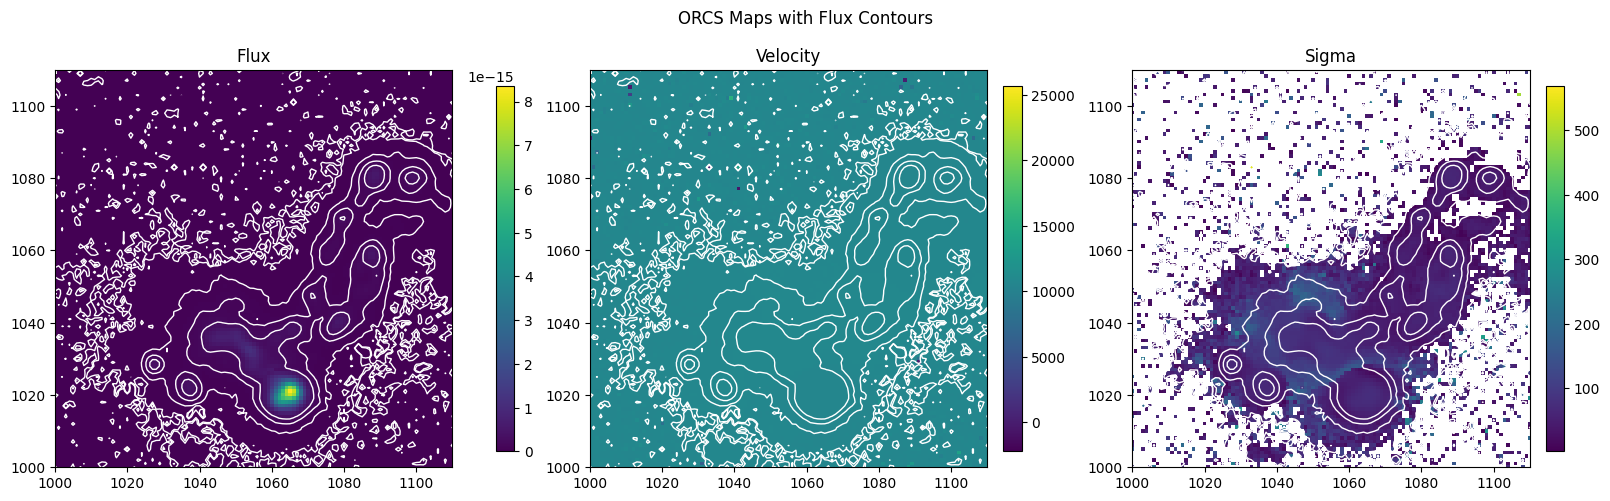

In [28]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Read ORCS maps
flux_map = orb.utils.io.read_fits(
    "/Users/leianydeoleo/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits"
)
vel_map = orb.utils.io.read_fits(
    "/Users/leianydeoleo/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.velocity.fits"
)
sig_map = orb.utils.io.read_fits(
    "/Users/leianydeoleo/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.all.1x1.sigma.fits"
)

# Compute contour levels from the flux map
finite = flux_map[np.isfinite(flux_map)]
levels = np.nanpercentile(finite, [70, 80, 90, 95, 98])

# List of backgrounds
backgrounds = [
    ("Flux", flux_map),
    ("Velocity", vel_map),
    ("Sigma", sig_map),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

for ax, (title, background) in zip(axes, backgrounds):

    # Display background
    im = ax.imshow(
        background.T,
        origin="lower",
        cmap="viridis"
    )

    # Overlay the SAME flux contours
    ax.contour(
        flux_map.T,
        levels=levels,
        colors="white",
        linewidths=1.0
    )

    ax.set_title(title)
    ax.set_xlim(1000, 1110)
    ax.set_ylim(1000, 1110)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("ORCS Maps with Flux Contours")
plt.show()

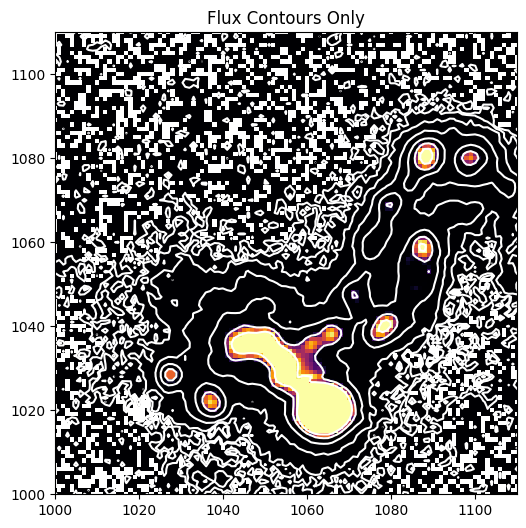

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


flux_map = orb.utils.io.read_fits(
    "/Users/leianydeoleo/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits"
)

flux_map_error = orb.utils.io.read_fits(
    "/Users/leianydeoleo/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux-err.fits"
)
finite_ha = flux_map[np.isfinite(flux_map)]

levels = np.nanpercentile(
    finite_ha,
    [70, 80, 85, 90, 95, 98, 99]
)

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    flux_map.T,
    origin="lower",
    cmap="inferno",
    norm=LogNorm(vmin=np.nanpercentile(finite, 0),
                 vmax=np.nanpercentile(finite, 99))
)
# Contours only
cs = ax.contour(
    flux_map.T,
    levels=levels,
    colors="white",
    linewidths=1.5
)

ax.set_title("Flux Contours Only")
ax.set_xlim(1000, 1110)
ax.set_ylim(1000, 1110)
ax.set_aspect("equal")

plt.show()

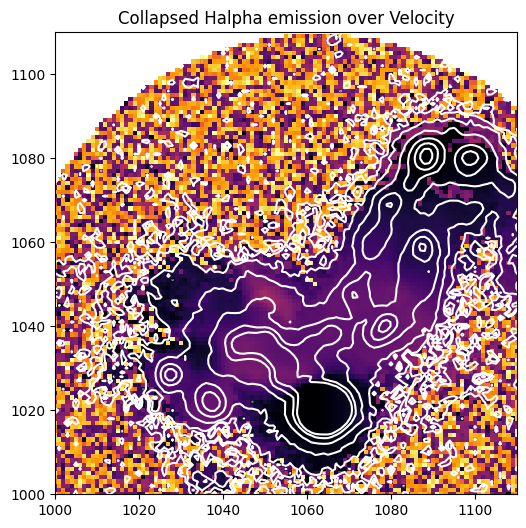

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

vel_map = orb.utils.io.read_fits(
    "/Users/leianydeoleo/Downloads/IIZw96_SN3.LineMaps.map.all.1x1.velocity.fits")
flux_map = orb.utils.io.read_fits(
    "/Users/leianydeoleo/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux.fits"
)

flux_map_error = orb.utils.io.read_fits(
    "/Users/leianydeoleo/IIZw96_SN3/MAPS/IIZw96_SN3.LineMaps.map.6563.1x1.flux-err.fits"
)
finite_ha = flux_map[np.isfinite(flux_map)]
finite_vel = vel_map[np.isfinite(vel_map) & (vel_map > 0)]

levels = np.nanpercentile(
    finite_ha,
    [70, 80, 85, 90, 95, 98, 99]
)

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    vel_map.T,
    origin="lower",
    cmap="inferno",
    norm=LogNorm(
        vmin=np.percentile(finite_vel,1),
        vmax=np.percentile(finite_vel,99)
    ) )
    
# Contours only
cs = ax.contour(
    flux_map.T,
    levels=levels,
    colors="white",
    linewidths=1.5
)

ax.set_title("Collapsed Halpha emission over Velocity")
ax.set_xlim(1000, 1110)
ax.set_ylim(1000, 1110)
ax.set_aspect("equal")

plt.show()